# Time Series Decomposition & Anomaly Attribution
This notebook demonstrates an end-to-end pipeline for multivariate time series analysis.
We generated a synthetic dataset perfectly balanced to demonstrate structural properties:
- **CPU_Usage**: Contains a massive mean-shift (Trend Break).
- **Memory_Usage**: Contains two cyclic breaks (Seasonal Deviations).
- **Network_Traffic**: Contains two isolated bursts (Irregular Spikes).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

# Ensure Jupyter can find the src modules from the parent directory
sys.path.append('..')

from src.data_generation import generate_synthetic_data
from src.preprocessing import load_and_preprocess
from src.decomposition import process_all_variables
from src.anomaly_detection import detect_and_compare
from src.attribution import detect_change_points, attribute_anomalies
from src.correlation import cross_correlation_analysis

os.makedirs('../outputs', exist_ok=True)

## 1. Data Generation & Preprocessing
Here we construct the baseline telemetry and standardize the scale.

Synthetic dataset created successfully at ../data/server_metrics.csv


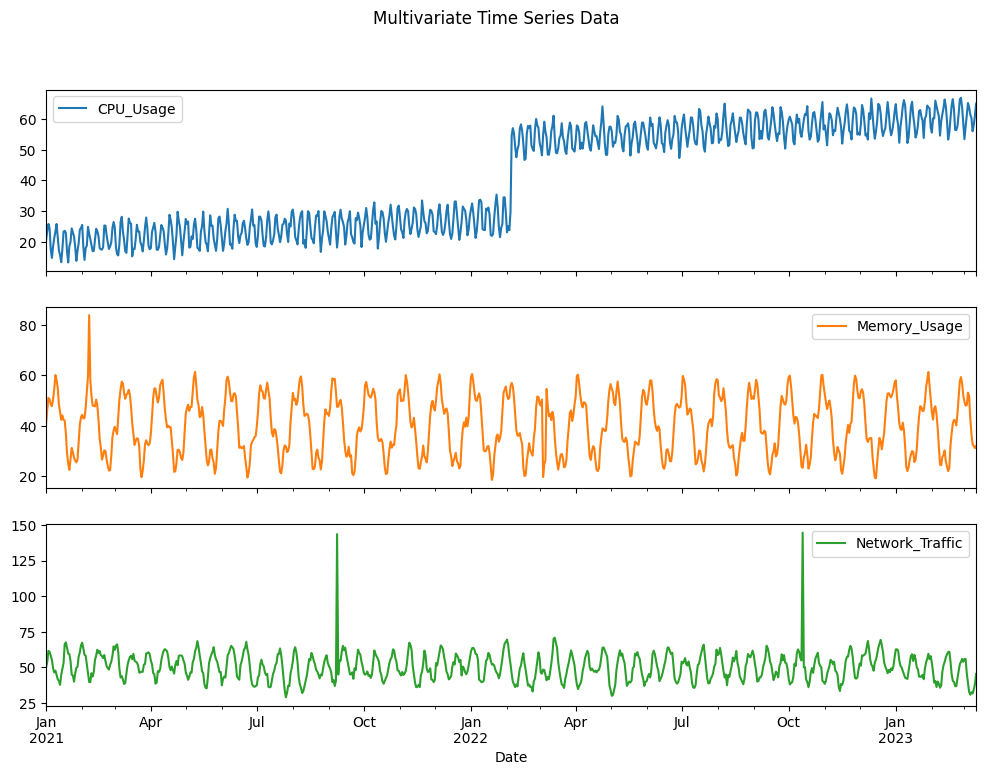

In [2]:
df_raw = generate_synthetic_data(output_path='../data/server_metrics.csv')
df, scaler = load_and_preprocess('../data/server_metrics.csv')

df.plot(subplots=True, figsize=(12, 8), title='Multivariate Time Series Data')
plt.show()

## 2. Time Series Decomposition (STL)
STL accurately splits the underlying mathematics into Trend, Seasonality, and Residuals.
- **Trend**: Underlying progression over time.
- **Seasonality**: Re-occurring cyclical patterns.
- **Residual**: The unpredictable noise.

In [3]:
decompositions, summary_df = process_all_variables(df)
summary_df.to_csv('../outputs/decomposition_summary.csv', index=False)
display(summary_df)

,Variable,Trend_Variance_%,Seasonal_Variance_%,Residual_Variance_%,High_Residual_Flag
0,CPU_Usage,94.83,4.34,0.83,No
1,Memory_Usage,80.08,12.32,7.60,No
2,Network_Traffic,6.68,32.04,61.29,Yes


## 3. Anomaly Detection & Attribution
We isolate residual threshold breaches using `IsolationForest` and `Z-Scores`. 
Then, a formalized rule-engine maps these mathematical breaches to their structural triggers:
1. **Trend Break**: Matches `ruptures` (PELT) structural mean/variance shifts.
2. **Seasonal Deviation**: Matches extremely intense seasonal bounds (>90th percentile).
3. **Irregular Spike**: Any residual noise not fitting the above parameters.


--- Processing CPU_Usage ---
Kappa Score (Z vs IF): 0.572


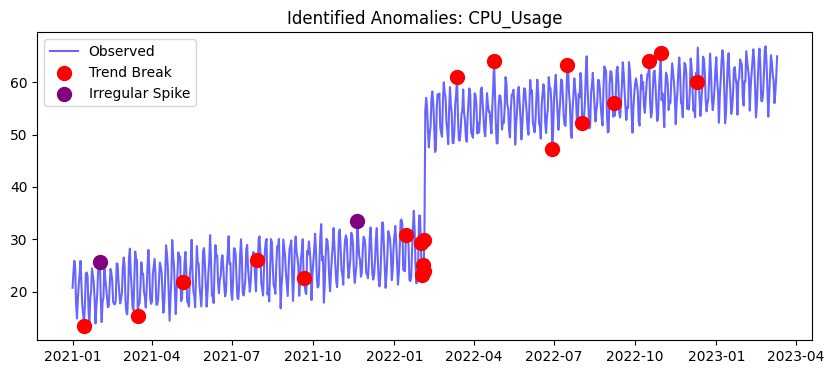


--- Processing Memory_Usage ---
Kappa Score (Z vs IF): 0.311


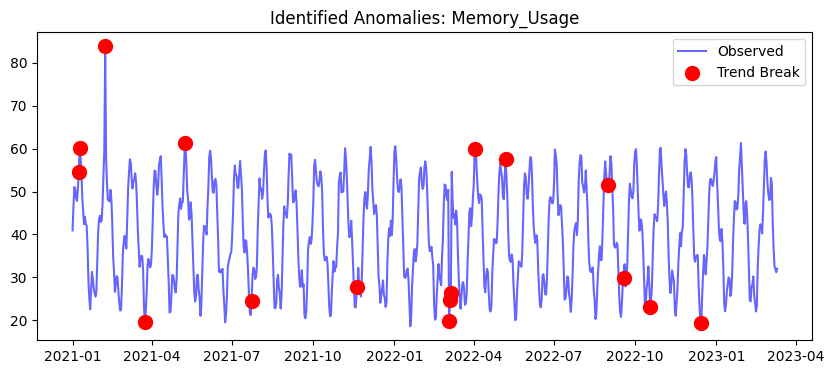


--- Processing Network_Traffic ---


Kappa Score (Z vs IF): 0.604


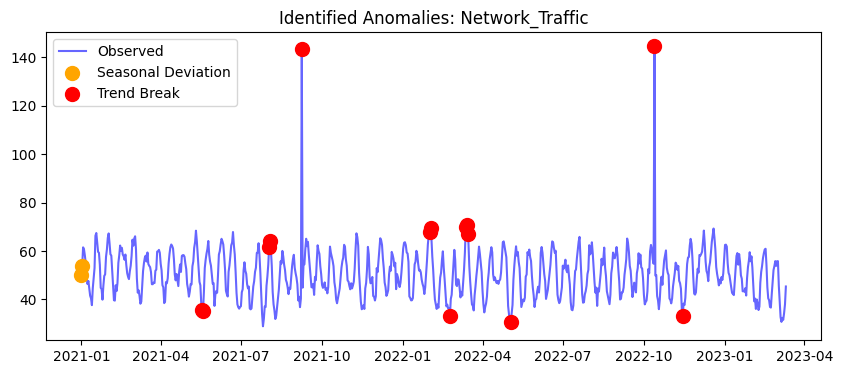

,Timestamp,Variable,Anomaly_Type,Observed_Val,Explanation
0,2021-01-14,CPU_Usage,Trend Break,13.48,Detected via PELT (ruptures). Anomaly coincide...
1,2021-02-01,CPU_Usage,Irregular Spike,25.57,Residual anomaly not explained by underlying t...
2,2021-03-16,CPU_Usage,Trend Break,15.38,Detected via PELT (ruptures). Anomaly coincide...
3,2021-05-06,CPU_Usage,Trend Break,21.88,Detected via PELT (ruptures). Anomaly coincide...
4,2021-07-29,CPU_Usage,Trend Break,26.05,Detected via PELT (ruptures). Anomaly coincide...
5,2021-09-20,CPU_Usage,Trend Break,22.55,Detected via PELT (ruptures). Anomaly coincide...
6,2021-11-20,CPU_Usage,Irregular Spike,33.51,Residual anomaly not explained by underlying t...
7,2022-01-14,CPU_Usage,Trend Break,30.84,Detected via PELT (ruptures). Anomaly coincide...
8,2022-01-31,CPU_Usage,Trend Break,29.37,Detected via PELT (ruptures). Anomaly coincide...
9,2022-02-01,CPU_Usage,Trend Break,23.18,Detected via PELT (ruptures). Anomaly coincide...


In [4]:
all_anomaly_logs = []
anomaly_colors = {'Trend Break': 'red', 'Seasonal Deviation': 'orange', 'Irregular Spike': 'purple'}

for var_name in df.columns:
    print(f"\n--- Processing {var_name} ---")
    decomp = decompositions[var_name]
    residual = decomp['Residual']
    
    # Detection
    final_anomalies, kappa, num_disag, _, _ = detect_and_compare(residual)
    print(f"Kappa Score (Z vs IF): {kappa:.3f}")
    
    # Attribution
    change_points = detect_change_points(df[var_name])
    attributions = attribute_anomalies(decomp, final_anomalies, change_points)
    
    if not attributions.empty:
        attributions['Variable'] = var_name
        all_anomaly_logs.append(attributions)
        
        # Plotting
        plt.figure(figsize=(10, 4))
        plt.plot(df.index, df[var_name], label='Observed', color='blue', alpha=0.6)
        
        for a_type in attributions['Anomaly_Type'].unique():
            anoms_of_type = attributions[attributions['Anomaly_Type'] == a_type]
            plt.scatter(anoms_of_type['Timestamp'], anoms_of_type['Observed_Val'], 
                        color=anomaly_colors.get(a_type, 'black'), s=100, label=a_type, zorder=5)
        
        plt.title(f"Identified Anomalies: {var_name}")
        plt.legend()
        plt.show()

if all_anomaly_logs:
    anomaly_log_df = pd.concat(all_anomaly_logs, ignore_index=True)
    anomaly_log_df = anomaly_log_df[['Timestamp', 'Variable', 'Anomaly_Type', 'Observed_Val', 'Explanation']]
    anomaly_log_df.to_csv('../outputs/anomaly_log.csv', index=False)
    display(anomaly_log_df)

## 4. Multivariate Analysis (Cross-Correlation)
By focusing entirely on the *residuals*, we strip away coincidental time-of-day relationships and only measure true causal dependency. A positive lag means the first variable acts as a **leading indicator** for the second.

,Variable_1,Variable_2,Max_Correlation,Lag_At_Max,Interpretation,Leading_Indicator_Meaning
0,CPU_Usage,Memory_Usage,-0.065,-6,Memory_Usage LEADS CPU_Usage by 6 days.,Because Memory_Usage spikes 6 days before CPU_...
1,CPU_Usage,Network_Traffic,-0.089,-3,Network_Traffic LEADS CPU_Usage by 3 days.,Because Network_Traffic spikes 3 days before C...
2,Memory_Usage,Network_Traffic,-0.119,9,Memory_Usage LEADS Network_Traffic by 9 days.,Because Memory_Usage spikes 9 days before Netw...


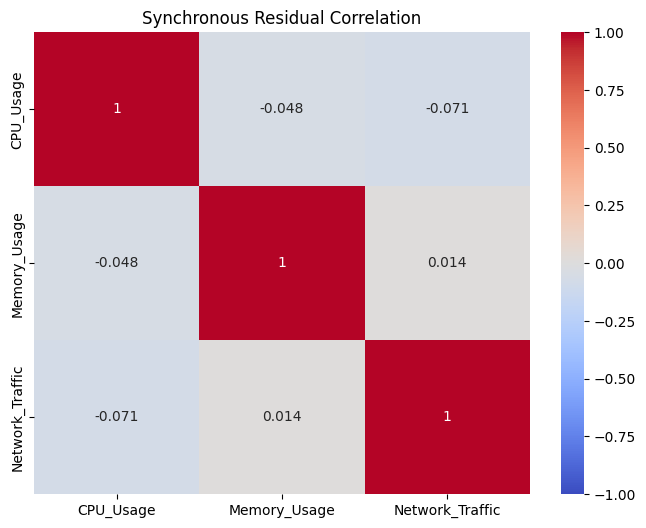

In [5]:
residuals_df = pd.DataFrame({var: decompositions[var]['Residual'] for var in df.columns})

correlation_report = cross_correlation_analysis(residuals_df, max_lag=15)
correlation_report.to_csv('../outputs/correlation_report.csv', index=False)

display(correlation_report)

plt.figure(figsize=(8, 6))
sns.heatmap(residuals_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Synchronous Residual Correlation")
plt.show()